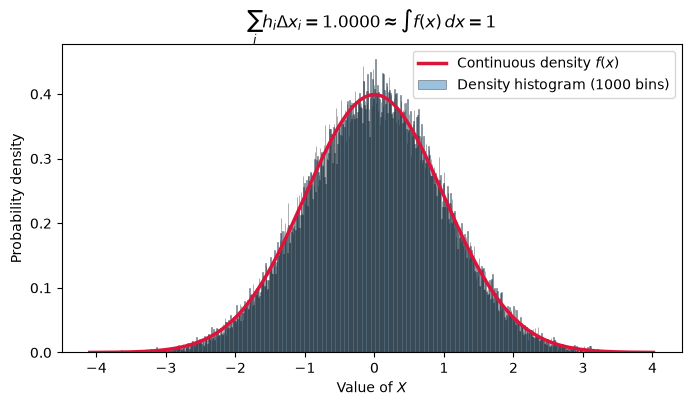

In [27]:
# code 0

bins = 1000
n = 100_000

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
sample = rng.normal(loc=0, scale=1, size=n)

# With density=True, each bar's *area* is probability, not its height.
heights, edges = np.histogram(sample, bins=bins, density=True)
widths = np.diff(edges)
histogram_area = np.sum(heights * widths)

# This is the continuous density that the histogram rectangles approximate.
x = np.linspace(edges[0], edges[-1], 800)
normal_density = np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)

fig, ax = plt.subplots(figsize=(8, 4))
# Draw every bin as a separate rectangle, including its vertical sides.
ax.bar(edges[:-1], heights, width=widths, align="edge", alpha=0.45,
       color="C0", edgecolor="black", linewidth=0.5,
       label=f"Density histogram ({bins} bins)")
ax.plot(x, normal_density, color="crimson", linewidth=2.5,
        label="Continuous density $f(x)$")
ax.set(
    xlabel="Value of $X$",
    ylabel="Probability density",
    title=rf"$\sum_i h_i \Delta x_i = {histogram_area:.4f} \approx \int f(x)\,dx = 1$",
)
ax.legend()
plt.show()


In [28]:
# code 1

from pathlib import Path
import pandas as pd

# Find the data file whether the notebook starts in this folder or the repository root.
search_folders = (Path.cwd(), *Path.cwd().parents)
data_file = next(
    (folder / "data" / "packet_loss.csv" for folder in search_folders
     if (folder / "data" / "packet_loss.csv").exists()),
    None,
)

if data_file is None:
    raise FileNotFoundError("Could not find data/packet_loss.csv")

loss = pd.read_csv(data_file)
print(loss["packet_lost"].value_counts().sort_index())
print("Number of packets:", len(loss))
print("Observed loss rate:", loss["packet_lost"].mean())


packet_lost
0    192
1      8
Name: count, dtype: int64
Number of packets: 200
Observed loss rate: 0.04


[0.58 0.84 0.94 0.98 1.  ]


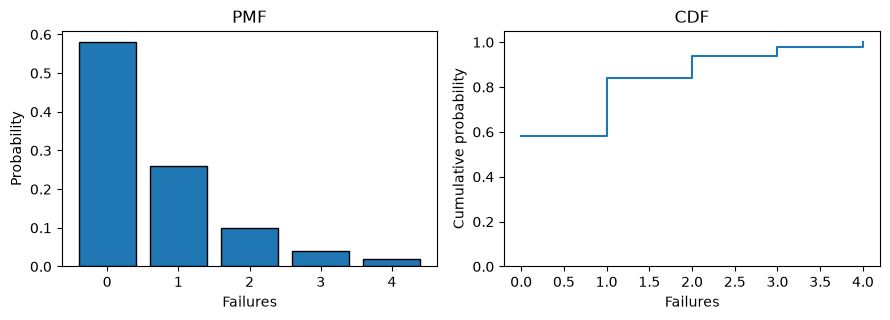

In [29]:
# code 2

import numpy as np
import matplotlib.pyplot as plt
x = np.array([0, 1, 2, 3, 4])
pmf = np.array([0.58, 0.26, 0.10, 0.04, 0.02])
cdf = np.cumsum(pmf)
print(cdf)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.3))
ax[0].bar(x, pmf, edgecolor="black")
ax[0].set(title="PMF", xlabel="Failures", ylabel="Probability")
ax[1].step(x, cdf, where="post")
ax[1].set(title="CDF", xlabel="Failures", ylabel="Cumulative probability",
ylim=(0, 1.05))
plt.tight_layout()

In [30]:
# code 3

mean = np.sum(x * pmf)
variance = np.sum(x**2 * pmf) - mean**2
sd = np.sqrt(variance)
print(f"mean = {mean:.2f}, variance = {variance:.4f}, standard deviation = {sd:.4f}")

mean = 0.66, variance = 0.9044, standard deviation = 0.9510


In [31]:
# code 4

from scipy.stats import binom

X = binom(n=50, p=0.04)

print("E[X] =", X.mean())       # binom.mean(50, 0.04) would also work
print("P(X = 2) =", X.pmf(2))   # binom.pmf(2, 50, 0.04) would also work
print("P(X <= 2) =", X.cdf(2))  # binom.cdf(2, 50, 0.04) would also work
print("P(X >= 5) =", X.sf(4))   # binom.sf(4, 50, 0.04) would also work
print("90% quantile =", X.ppf(0.90)) # binom.ppf(0.90, 50, 0.04) would also work

E[X] = 2.0
P(X = 2) = 0.27623280740364115
P(X <= 2) = 0.6767140040965933
P(X >= 5) = 0.04897147188451279
90% quantile = 4.0


In [36]:
# Code 5

from scipy.stats import poisson
mu_8 = 1.6
Y_8 = poisson(mu=1.6)
Y_24 = poisson(mu=3*1.6)
print("P(no stop in 8h) =", Y_8.pmf(0))
print("P(at least 3 in 8h) =", Y_8.sf(3-1))
print("P(at least 3 in 24h) =", Y_24.sf(3-1))

P(no stop in 8h) = 0.20189651799465538
P(at least 3 in 8h) = 0.216641510180737
P(at least 3 in 24h) = 0.8574607811109731
